## Extension 5: Changing How the Learning Rate is Decayed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from image_datasets import get_dataset, train_val_split
from image_datasets import preprocess_nonlinear

from hebb_net import HebbNet
from decoder_nets import LinearDecoder, NonlinearDecoder

# New imports
from extension_jacob import DeepNetwork_Extended, LinearDecoder_Extended, NonlinearDecoder_Extended

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

### Loading in and Prepping CIFAR-10 Data

In [2]:
X_train, Y_train, X_test, Y_test = get_dataset('cifar10', norm_method='center', verbose=False)
X_train, Y_train, X_val, Y_val = train_val_split(X_train, Y_train)

M = X_train.shape[1]
hebb_net = HebbNet(M, 2000, k=2, inhib_value=-0.4, load_wts=True, saved_wts_path='weights/cifar10_wts.npy')

hebb_train_netIn = hebb_net.net_in(X_train)
hebb_test_netIn = hebb_net.net_in(X_test)
hebb_val_netIn = hebb_net.net_in(X_val)

I0000 00:00:1773235854.517512 1256657 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773235854.517599 1256657 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded stored wts.


### Part 1: Linear Decoders

#### Hyperparameters to Test Impact of Different Learning Rate Decay

In [3]:
max_epochs = 50 # approximate epochs used in baseline
batch_size = 256 # same as base project
patience = 100 # high to isolate for lr_decay
lr_patience = 3 # same as base project
lr_max_decays = 12 # higher to get better sense for effect
lr_decay_amount = 0.00005 # amount to subtract

#### Baseline: Linear Decoder With Typical Learning Rate Decay

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/50, Training loss 2.192, Val loss 2.041, Val acc 0.2989. Epoch took: 2.6 secs
Epoch 2/50, Training loss 2.041, Val loss 1.999, Val acc 0.3109. Epoch took: 2.3 secs
Epoch 3/50, Training loss 2.015, Val loss 2.018, Val acc 0.3063. Epoch took: 2.3 secs
Epoch 4/50, Training loss 2.016, Val loss 2.033, Val acc 0.3241. Epoch took: 2.3 secs
Epoch 5/50, Training loss 1.998, Val loss 1.884, Val acc 0.3456. Epoch took: 2.4 secs
Epoch 6/50, Training loss 1.998, Val loss 2.090, Val acc 0.2995. Epoch took: 2.3 secs
Epoch 7/50, Training loss 1.994, Val loss 2.057, Val acc 0.3233. Epoch took: 2.2 secs
Learning rate before decay: 0.0010000000474974513 --> Learning rate after decay: 0.0005000000237487257
Epoch 8/50, Training loss 1.982, Val loss 2.058, Val acc 0.3087. Epoch took: 2.3 secs
Epoch 9/5

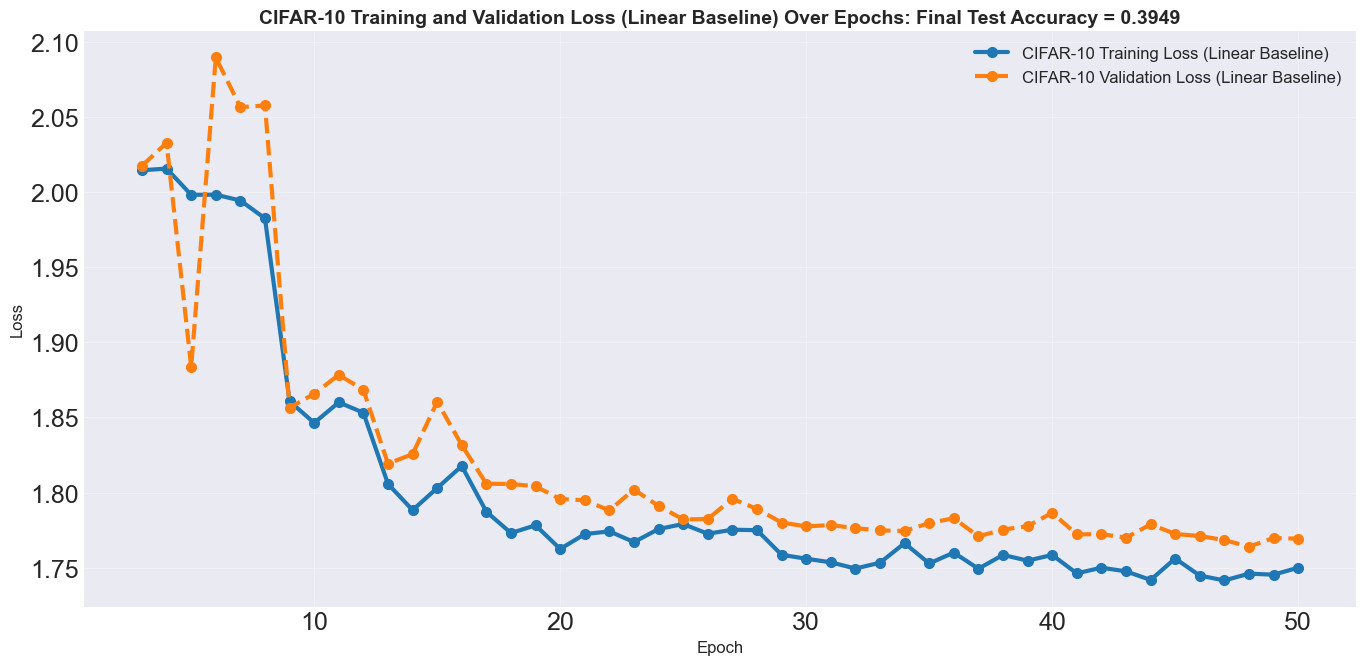

In [4]:
tf.random.set_seed(0)

baseline = LinearDecoder(input_feats_shape=(hebb_train_netIn.shape[1],), C=10)
baseline.compile()

train_loss_hist, val_loss_hist, val_acc_hist, e = baseline.fit(hebb_train_netIn, Y_train, x_val=hebb_val_netIn, y_val=Y_val, 
                                                               max_epochs=50, batch_size=256, patience=100, 
                                                               lr_patience=3, lr_max_decays=12)

test_acc, test_loss = baseline.evaluate(hebb_test_netIn, Y_test)
print(f'CIFAR-10 Test Accuracy (Linear Baseline ): {test_acc:.4f}')

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e']
line_styles = ['-', '--']

epochs = list(range(1, e+2))
epochs = epochs[2:]

train_loss_hist_truncated = train_loss_hist[2:]
val_loss_hist_truncated = val_loss_hist[2:]

plt.plot(epochs, train_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Training Loss (Linear Baseline)', 
             color=colors[0], linestyle=line_styles[0])

plt.plot(epochs, val_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Validation Loss (Linear Baseline)', 
             color=colors[1], linestyle=line_styles[1])

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'CIFAR-10 Training and Validation Loss (Linear Baseline) Over Epochs: Final Test Accuracy = {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Linear Decoder With Linear Decay 

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/50, Training loss 2.192, Val loss 2.041, Val acc 0.2989. Epoch took: 2.8 secs
Epoch 2/50, Training loss 2.041, Val loss 1.999, Val acc 0.3109. Epoch took: 2.4 secs
Epoch 3/50, Training loss 2.015, Val loss 2.018, Val acc 0.3063. Epoch took: 2.2 secs
Epoch 4/50, Training loss 2.016, Val loss 2.033, Val acc 0.3241. Epoch took: 2.4 secs
Epoch 5/50, Training loss 1.998, Val loss 1.884, Val acc 0.3456. Epoch took: 2.2 secs
Epoch 6/50, Training loss 1.998, Val loss 2.090, Val acc 0.2995. Epoch took: 2.3 secs
Epoch 7/50, Training loss 1.994, Val loss 2.057, Val acc 0.3233. Epoch took: 2.2 secs
Learning rate before decay: 0.0010000000474974513 --> Learning rate after decay: 0.0009500000742264092
Epoch 8/50, Training loss 1.982, Val loss 2.058, Val acc 0.3087. Epoch took: 2.2 secs
Epoch 9/5

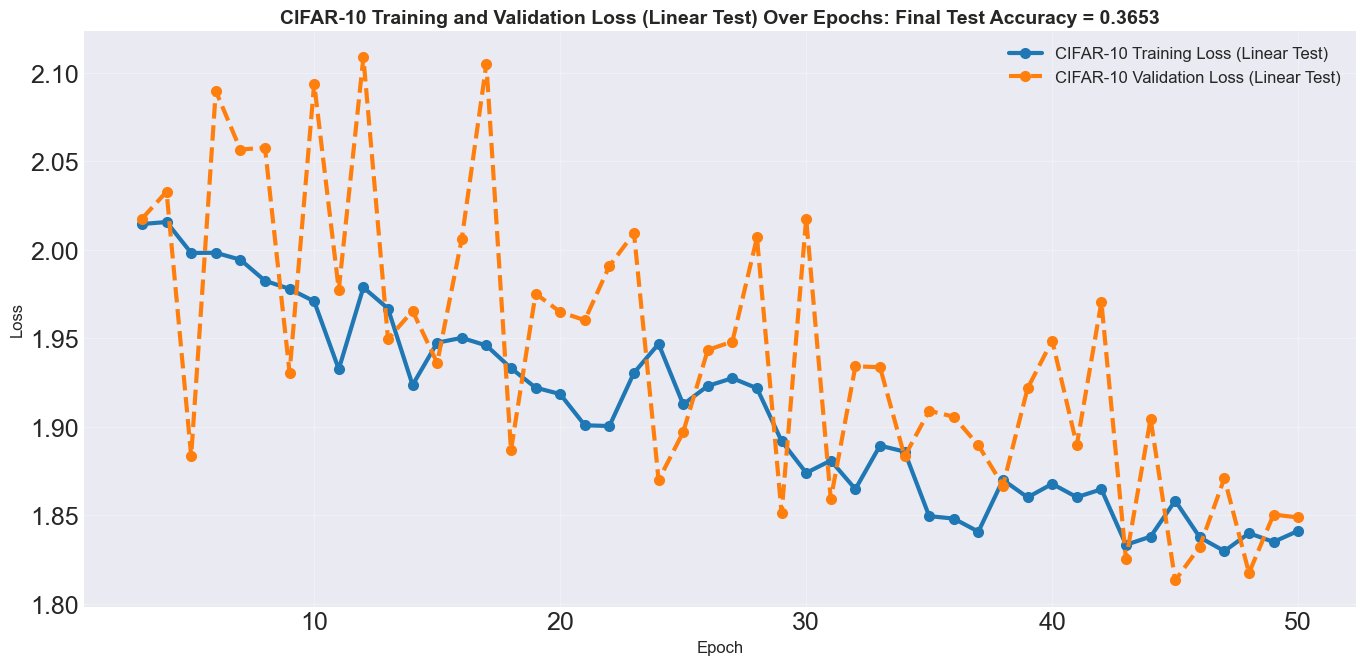

In [5]:
tf.random.set_seed(0)

test = LinearDecoder_Extended(input_feats_shape=(hebb_train_netIn.shape[1],), C=10)
test.compile()

train_loss_hist, val_loss_hist, val_acc_hist, e = test.fit(hebb_train_netIn, Y_train, x_val=hebb_val_netIn, y_val=Y_val, 
                                                           max_epochs=50, batch_size=256, patience=100, 
                                                           lr_patience=3, lr_max_decays=12, lr_decay_amount=0.00005)

test_acc, test_loss = test.evaluate(hebb_test_netIn, Y_test)
print(f'CIFAR-10 Test Accuracy (Linear Test): {test_acc:.4f}')

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e']
line_styles = ['-', '--']

epochs = list(range(1, e+2))
epochs = epochs[2:]

train_loss_hist_truncated = train_loss_hist[2:]
val_loss_hist_truncated = val_loss_hist[2:]

plt.plot(epochs, train_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Training Loss (Linear Test)', 
             color=colors[0], linestyle=line_styles[0])

plt.plot(epochs, val_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Validation Loss (Linear Test)', 
             color=colors[1], linestyle=line_styles[1])

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'CIFAR-10 Training and Validation Loss (Linear Test) Over Epochs: Final Test Accuracy = {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part 2: Non-Linear Decoders

#### Hyperparameters to Test Impact of Different Learning Rate Decay

In [6]:
max_epochs = 150 # approximate epochs used in baseline
patience = 100 # high to isolate for lr_decay
lr_patience = 5 # same as base project
lr_max_decays = 12 # higher to get better sense for effect
lr_decay_amount = 0.00005 # amount to subtract1
m = 4.0 # same as base project
c = 2.0 # same as base project

#### Extra Preprocessing

In [7]:
hebb_train_netIn = preprocess_nonlinear(hebb_train_netIn, n=2.0)
hebb_test_netIn = preprocess_nonlinear(hebb_test_netIn, n=2.0)
hebb_val_netIn = preprocess_nonlinear(hebb_val_netIn, n=2.0)

#### Baseline: Linear Decoder With Typical Learning Rate Decay

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/150, Training loss 0.524, Val loss 0.473, Val acc 0.3610. Epoch took: 6.0 secs
Epoch 2/150, Training loss 0.460, Val loss 0.454, Val acc 0.3818. Epoch took: 6.0 secs
Epoch 3/150, Training loss 0.445, Val loss 0.445, Val acc 0.3918. Epoch took: 5.8 secs
Epoch 4/150, Training loss 0.434, Val loss 0.435, Val acc 0.4089. Epoch took: 6.0 secs
Epoch 5/150, Training loss 0.428, Val loss 0.432, Val acc 0.4111. Epoch took: 5.9 secs
Epoch 6/150, Training loss 0.428, Val loss 0.427, Val acc 0.4219. Epoch took: 5.9 secs
Epoch 7/150, Training loss 0.421, Val loss 0.425, Val acc 0.4185. Epoch took: 5.9 secs
Epoch 8/150, Training loss 0.418, Val loss 0.422, Val acc 0.4269. Epoch took: 5.8 secs
Epoch 9/150, Training loss 0.414, Val loss 0.421, Val acc 0.4257. Epoch took: 7.2 secs
Epoch 10/150, Tra

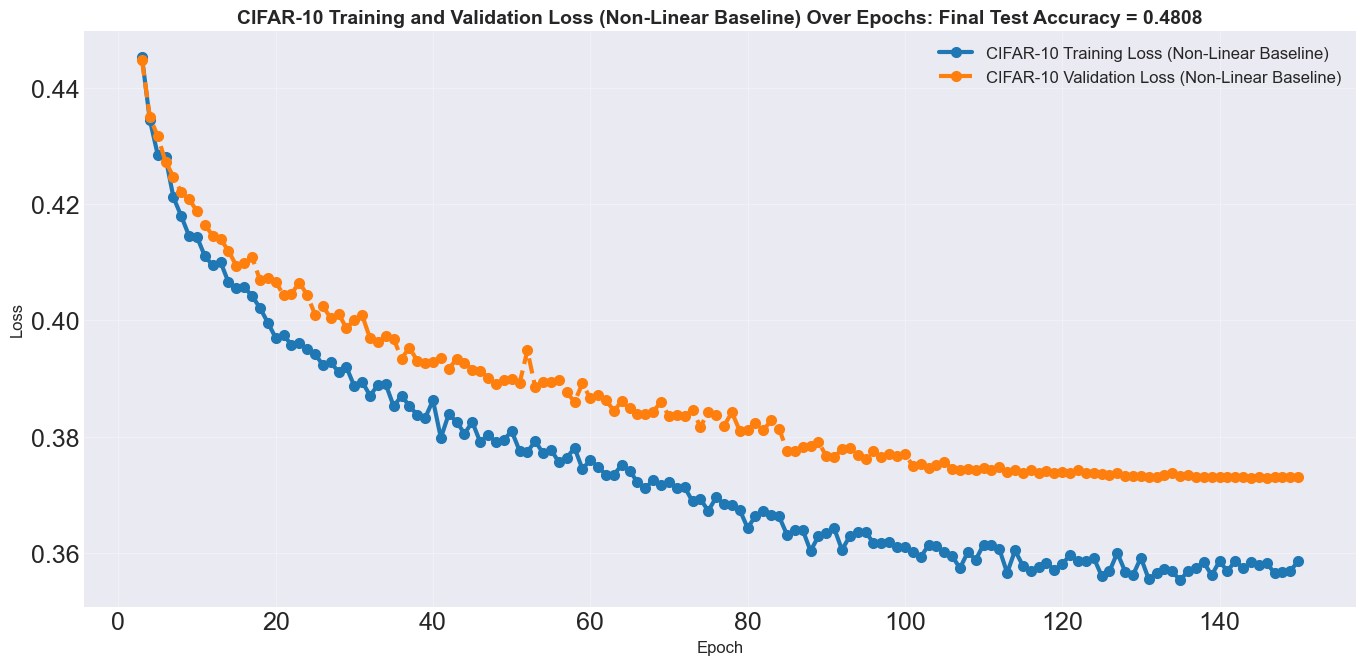

In [8]:
tf.random.set_seed(0)

M = hebb_train_netIn.shape[1]  
C = 10 

baseline = NonlinearDecoder((M,), C, loss_exp=4.0)
baseline.output_layer.loss_exp = 4.0
baseline.compile(loss='lp')

train_loss_hist, val_loss_hist, val_acc_hist, e = baseline.fit(hebb_train_netIn, Y_train, x_val=hebb_val_netIn, y_val=Y_val, 
                                                               max_epochs=150, patience=100, lr_patience=5, lr_max_decays=12)

test_acc, test_loss= baseline.evaluate(hebb_test_netIn, Y_test)
print(f'CIFAR-10 Test Accuracy (Non-Linear Baseline): {test_acc:.4f}')

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e']
line_styles = ['-', '--']

epochs = list(range(1, e+2))
epochs = epochs[2:]

train_loss_hist_truncated = train_loss_hist[2:]
val_loss_hist_truncated = val_loss_hist[2:]

plt.plot(epochs, train_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Training Loss (Non-Linear Baseline)', 
             color=colors[0], linestyle=line_styles[0])

plt.plot(epochs, val_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Validation Loss (Non-Linear Baseline)', 
             color=colors[1], linestyle=line_styles[1])

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'CIFAR-10 Training and Validation Loss (Non-Linear Baseline) Over Epochs: Final Test Accuracy = {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Non-Linear Decoder With Linear Decay 

---------------------------------------------------------------------------
Dense layer output(Output Layer) shape: [1, 10]
---------------------------------------------------------------------------
Epoch 1/150, Training loss 0.524, Val loss 0.473, Val acc 0.3610. Epoch took: 6.3 secs
Epoch 2/150, Training loss 0.460, Val loss 0.454, Val acc 0.3818. Epoch took: 6.0 secs
Epoch 3/150, Training loss 0.445, Val loss 0.445, Val acc 0.3918. Epoch took: 6.1 secs
Epoch 4/150, Training loss 0.434, Val loss 0.435, Val acc 0.4089. Epoch took: 6.6 secs
Epoch 5/150, Training loss 0.428, Val loss 0.432, Val acc 0.4111. Epoch took: 6.4 secs
Epoch 6/150, Training loss 0.428, Val loss 0.427, Val acc 0.4219. Epoch took: 6.6 secs
Epoch 7/150, Training loss 0.421, Val loss 0.425, Val acc 0.4185. Epoch took: 6.9 secs
Epoch 8/150, Training loss 0.418, Val loss 0.422, Val acc 0.4269. Epoch took: 7.2 secs
Epoch 9/150, Training loss 0.414, Val loss 0.421, Val acc 0.4257. Epoch took: 7.1 secs
Epoch 10/150, Tra

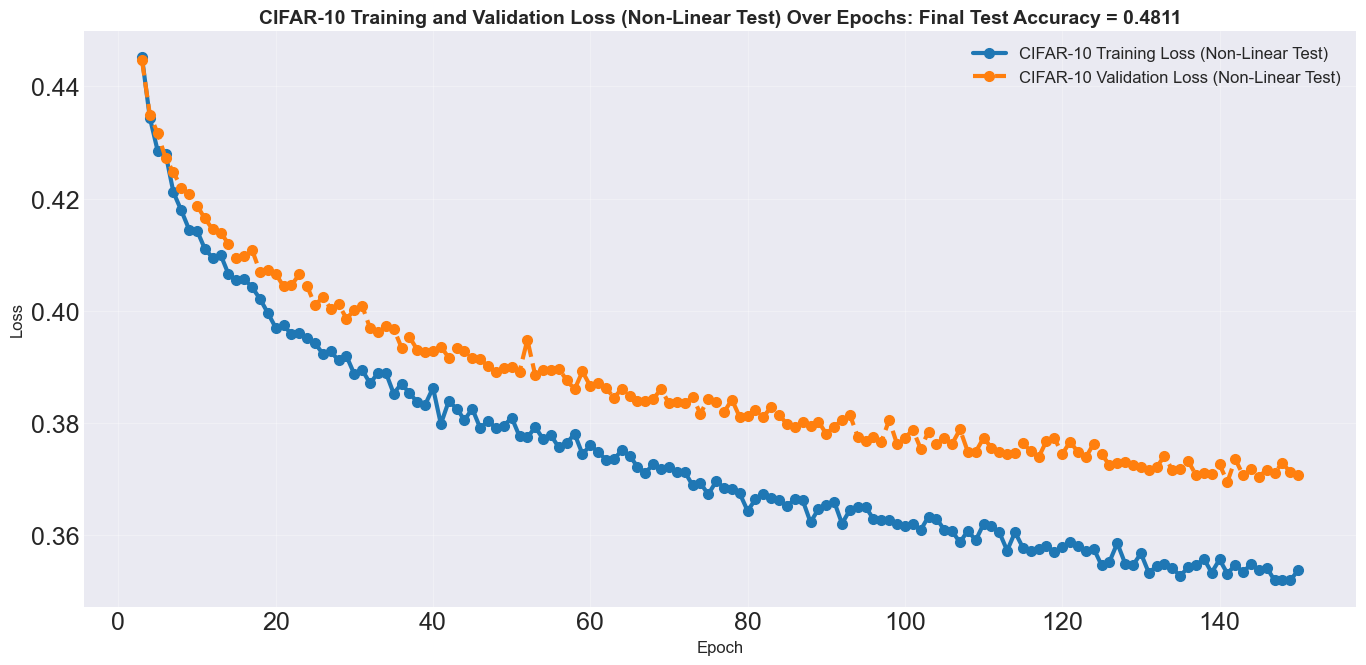

In [9]:
tf.random.set_seed(0)

M = hebb_train_netIn.shape[1]  
C = 10 

test = NonlinearDecoder_Extended((M,), C, loss_exp=4.0)
test.output_layer.loss_exp = 4.0
test.compile(loss='lp')

train_loss_hist, val_loss_hist, val_acc_hist, e = test.fit(hebb_train_netIn, Y_train, x_val=hebb_val_netIn, y_val=Y_val, 
                                                           max_epochs=150, patience=100, lr_patience=5, lr_max_decays=12, 
                                                           lr_decay_amount=0.00005)

test_acc, test_loss= test.evaluate(hebb_test_netIn, Y_test)
print(f'CIFAR-10 Test Accuracy (Non-Linear Test): {test_acc:.4f}')

plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e']
line_styles = ['-', '--']

epochs = list(range(1, e+2))
epochs = epochs[2:]

train_loss_hist_truncated = train_loss_hist[2:]
val_loss_hist_truncated = val_loss_hist[2:]

plt.plot(epochs, train_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Training Loss (Non-Linear Test)', 
             color=colors[0], linestyle=line_styles[0])

plt.plot(epochs, val_loss_hist_truncated,  
             marker='o', linewidth=3, markersize=7,
             label='CIFAR-10 Validation Loss (Non-Linear Test)', 
             color=colors[1], linestyle=line_styles[1])

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'CIFAR-10 Training and Validation Loss (Non-Linear Test) Over Epochs: Final Test Accuracy = {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()